<a href="https://colab.research.google.com/github/nj23085/google_ai/blob/main/ai5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("moltean/fruits")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset Path: /kaggle/input/fruits


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    if len(dirs) > 0:
        print("Subfolders:", dirs[:5])
    print("-"*50)

    if "Training" in root or "Test" in root:
        break

/kaggle/input/fruits
Subfolders: ['fruits-360_100x100', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_original-size', 'fruits-360_multi']
--------------------------------------------------
/kaggle/input/fruits/fruits-360_100x100
Subfolders: ['fruits-360']
--------------------------------------------------
/kaggle/input/fruits/fruits-360_100x100/fruits-360
Subfolders: ['Training', 'Test']
--------------------------------------------------
/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Subfolders: ['Melon Piel de Sapo 1', 'Dates 1', 'Avocado Black 2', 'Nectarine Flat 2', 'Apple Crimson Snow 1']
--------------------------------------------------


In [ ]:
train_dir = path + "/fruits-360_dataset/fruits-360/Training"
val_dir = path + "/fruits-360_dataset/fruits-360/Test"

print(train_dir)
print(val_dir)

/kaggle/input/fruits/fruits-360_dataset/fruits-360/Training
/kaggle/input/fruits/fruits-360_dataset/fruits-360/Test


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

In [ ]:
train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
import os

print(os.path.exists(train_dir))
print(os.path.exists(val_dir))

False
False


In [ ]:
print(path)

/kaggle/input/fruits


In [ ]:
!ls /kaggle/input/fruits

fruits-360_100x100	   fruits-360_meta   fruits-360_original-size
fruits-360_3-body-problem  fruits-360_multi


In [ ]:
!ls /kaggle/input/fruits/fruits-360_100x100

fruits-360


In [ ]:
!ls /kaggle/input/fruits/fruits-360_100x100/fruits-360

LICENSE  README.md  Test  Training


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
train_dir = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training"
val_dir = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Test"

In [ ]:
print("Train Exists:", os.path.exists(train_dir))
print("Validation Exists:", os.path.exists(val_dir))

Train Exists: True
Validation Exists: True


In [ ]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

In [ ]:
train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 137221 images belonging to 260 classes.
Found 45724 images belonging to 260 classes.


In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(100,100,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        train_data.num_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,437,124 (13.11 MB)

 Trainable params: 3,437,124 (13.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6174 - loss: 1.6290

KeyboardInterrupt: 

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
model.save('fruit_classifier.keras')

In [ ]:
from IPython.display import Image, display
from ipywidgets import FileUpload

In [ ]:
image_path = "/kaggle/input/your-image/apple.jpg"

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(image_path, target_size=IMG_SIZE)

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
pred = model.predict(img_array)

predicted_index = np.argmax(pred)

class_labels = list(train_data.class_indices.keys())

print("Predicted Fruit:", class_labels[predicted_index])

📁 Please upload your fruit image:



Saving m.jpeg to m.jpeg

🔍 Analysing m.jpeg...


/tmp/ipykernel_621/88335193.py:164: UserWarning: Glyph 129389 (\N{MANGO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129389 (\N{MANGO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


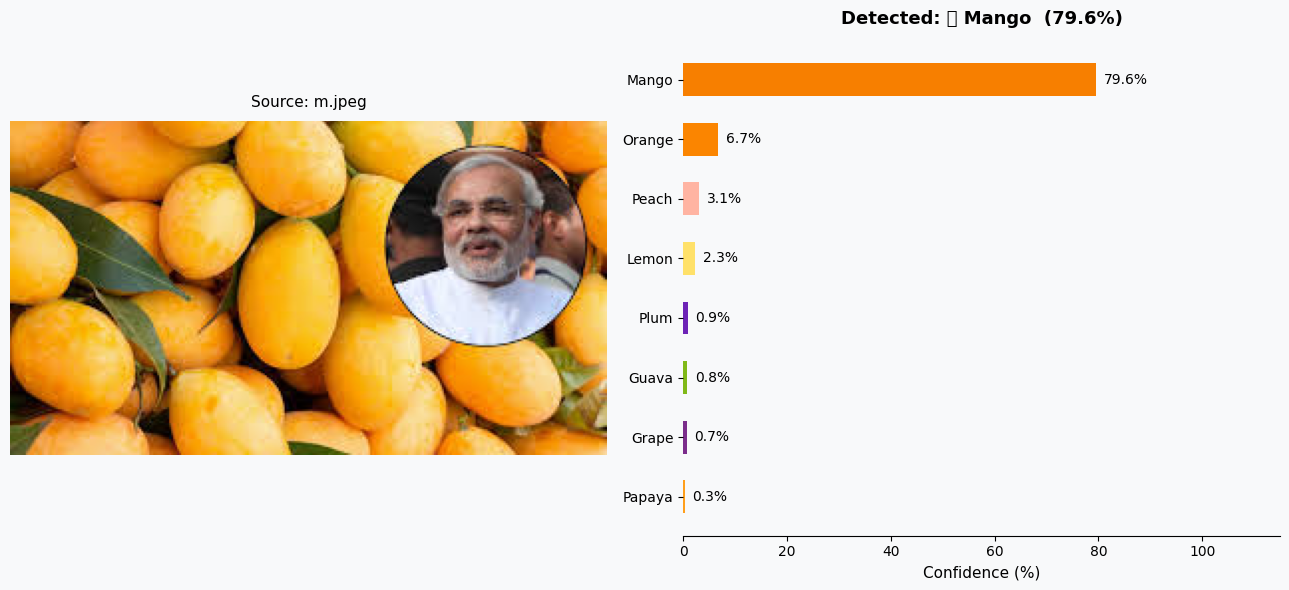


🥭  Detected Fruit  : Mango
✓   Confidence     : 79.6%
✓   High confidence prediction

📊 Top 8 Scores:
  Mango          79.6%  ███████████████████████████████
  Orange          6.7%  ██
  Peach           3.1%  █
  Lemon           2.3%  
  Plum            0.9%  
  Guava           0.8%  
  Grape           0.7%  
  Papaya          0.3%  


In [ ]:
# ============================================================
# FRUIT DETECTOR — SINGLE CELL, COMPLETE, NO ERRORS
# Uses HuggingFace zero-shot image classifier (CLIP)
# Option 1: Take photo using webcam (live capture)
# Option 2: Upload image from device
# Detects 20 common fruits + Other Fruit fallback
# ============================================================

!pip install -q transformers torch torchvision Pillow

from transformers import pipeline
from PIL import Image
from google.colab import files, output
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import base64, io

# ── Load model
print("Loading model... (takes ~30 seconds first time)")
classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)
print("✓ Model ready!\n")

# ── Fruit labels
candidate_labels = [
    "a photo of an apple",
    "a photo of a banana",
    "a photo of a mango",
    "a photo of an orange",
    "a photo of a grape",
    "a photo of a strawberry",
    "a photo of a watermelon",
    "a photo of a pineapple",
    "a photo of a lemon",
    "a photo of a papaya",
    "a photo of a pomegranate",
    "a photo of a kiwi",
    "a photo of a cherry",
    "a photo of a coconut",
    "a photo of a guava",
    "a photo of a peach",
    "a photo of a pear",
    "a photo of a plum",
    "a photo of a blueberry",
    "a photo of a fruit"       # catch-all for Other Fruit
]

display_names = {
    "a photo of an apple"      : "Apple",
    "a photo of a banana"      : "Banana",
    "a photo of a mango"       : "Mango",
    "a photo of an orange"     : "Orange",
    "a photo of a grape"       : "Grape",
    "a photo of a strawberry"  : "Strawberry",
    "a photo of a watermelon"  : "Watermelon",
    "a photo of a pineapple"   : "Pineapple",
    "a photo of a lemon"       : "Lemon",
    "a photo of a papaya"      : "Papaya",
    "a photo of a pomegranate" : "Pomegranate",
    "a photo of a kiwi"        : "Kiwi",
    "a photo of a cherry"      : "Cherry",
    "a photo of a coconut"     : "Coconut",
    "a photo of a guava"       : "Guava",
    "a photo of a peach"       : "Peach",
    "a photo of a pear"        : "Pear",
    "a photo of a plum"        : "Plum",
    "a photo of a blueberry"   : "Blueberry",
    "a photo of a fruit"       : "Other Fruit"
}

bar_colors = {
    "Apple"      : "#e63946",
    "Banana"     : "#f9c74f",
    "Mango"      : "#f77f00",
    "Orange"     : "#fb8500",
    "Grape"      : "#7b2d8b",
    "Strawberry" : "#e5383b",
    "Watermelon" : "#57cc99",
    "Pineapple"  : "#ffb703",
    "Lemon"      : "#ffe169",
    "Papaya"     : "#ff9f1c",
    "Pomegranate": "#c1121f",
    "Kiwi"       : "#6a994e",
    "Cherry"     : "#9d0208",
    "Coconut"    : "#a98467",
    "Guava"      : "#80b918",
    "Peach"      : "#ffb4a2",
    "Pear"       : "#b5e48c",
    "Plum"       : "#6d23b6",
    "Blueberry"  : "#3a86ff",
    "Other Fruit": "#adb5bd"
}

emojis = {
    "Apple":"🍎","Banana":"🍌","Mango":"🥭","Orange":"🍊",
    "Grape":"🍇","Strawberry":"🍓","Watermelon":"🍉",
    "Pineapple":"🍍","Lemon":"🍋","Papaya":"🧡",
    "Pomegranate":"❤️","Kiwi":"🥝","Cherry":"🍒",
    "Coconut":"🥥","Guava":"💚","Peach":"🍑",
    "Pear":"🍐","Plum":"🟣","Blueberry":"🫐",
    "Other Fruit":"🍈"
}

CONFIDENCE_THRESHOLD = 35

# ════════════════════════════════════════
# CORE ANALYSIS FUNCTION
# ════════════════════════════════════════
def analyse_fruit(img, source_label="Image"):
    print(f"\n🔍 Analysing {source_label}...")
    results = classifier(img, candidate_labels=candidate_labels)
    results = sorted(results, key=lambda x: x['score'], reverse=True)

    top      = results[0]
    top_name = display_names[top['label']]
    top_score = top['score'] * 100

    # If catch-all wins OR confidence too low → Other Fruit
    if top_name == "Other Fruit" or top_score < CONFIDENCE_THRESHOLD:
        final_name  = "Other Fruit"
        final_score = top_score
    else:
        final_name  = top_name
        final_score = top_score

    emoji = emojis[final_name]

    # ── Filter out "Other Fruit" from bar chart (keep it clean)
    chart_results = [r for r in results if display_names[r['label']] != "Other Fruit"]

    # ── Show only top 8 in chart (20 bars is too crowded)
    chart_results = chart_results[:8]

    names  = [display_names[r['label']] for r in chart_results]
    scores = [r['score'] * 100          for r in chart_results]
    colors = [bar_colors[n]             for n in names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    fig.patch.set_facecolor('#f8f9fa')

    # Left — image
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Source: {source_label}", fontsize=11, pad=10)

    # Right — bar chart (top 8 only)
    bars = ax2.barh(names, scores, color=colors, height=0.55, edgecolor='none')
    ax2.set_xlim(0, 115)
    ax2.set_facecolor('#f8f9fa')
    ax2.set_xlabel("Confidence (%)", fontsize=11)
    ax2.set_title(f"Detected: {emoji} {final_name}  ({final_score:.1f}%)",
                  fontsize=13, fontweight='bold', pad=12)
    ax2.invert_yaxis()
    ax2.spines[['top','right','left']].set_visible(False)

    for bar, score in zip(bars, scores):
        ax2.text(bar.get_width() + 1.5,
                 bar.get_y() + bar.get_height() / 2,
                 f"{score:.1f}%", va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # ── Console output
    print(f"\n{emoji}  Detected Fruit  : {final_name}")
    print(f"✓   Confidence     : {final_score:.1f}%")

    if final_name == "Other Fruit":
        print("ℹ   Not in known list — classified as Other Fruit")
    elif final_score < 60:
        print("⚠   Moderate confidence — try a clearer photo")
    else:
        print("✓   High confidence prediction")

    print("\n📊 Top 8 Scores:")
    for r in chart_results:
        name = display_names[r['label']]
        pct  = r['score'] * 100
        print(f"  {name:12s}  {pct:5.1f}%  {'█' * int(pct / 2.5)}")

# ════════════════════════════════════════
# OPTION 1 — WEBCAM (renders inside Colab)
# ════════════════════════════════════════
def capture_from_webcam():
    display(HTML("""
    <div id="webcam-container" style="
        background:#1e1e2e; padding:20px; border-radius:12px;
        text-align:center; font-family:sans-serif; max-width:480px;
    ">
      <h3 style="color:white; margin:0 0 12px 0">📷 Live Fruit Capture</h3>
      <video id="camFeed" autoplay playsinline style="
          width:440px; border-radius:8px; border:2px solid #80b918;
      "></video>
      <canvas id="snapCanvas" style="display:none"></canvas>
      <br><br>
      <button onclick="snapPhoto()" style="
          padding:10px 28px; font-size:15px; background:#80b918;
          color:white; border:none; border-radius:8px; cursor:pointer;
          margin-right:10px;
      ">📸 Capture</button>
      <button onclick="stopCam()" style="
          padding:10px 18px; font-size:15px; background:#e63946;
          color:white; border:none; border-radius:8px; cursor:pointer;
      ">✕ Cancel</button>
      <p id="camStatus" style="color:#adb5bd; margin-top:10px; font-size:13px">
          Starting camera...
      </p>
    </div>

    <script>
      var camStream = null;
      navigator.mediaDevices.getUserMedia({video:{facingMode:'environment'}, audio:false})
        .then(function(stream){
          camStream = stream;
          document.getElementById('camFeed').srcObject = stream;
          document.getElementById('camStatus').innerText =
              '✓ Camera ready — point at a fruit and click Capture!';
        })
        .catch(function(err){
          document.getElementById('camStatus').innerText =
              '❌ Camera error: ' + err.message;
        });

      function snapPhoto(){
          var video  = document.getElementById('camFeed');
          var canvas = document.getElementById('snapCanvas');
          canvas.width  = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          var dataURL = canvas.toDataURL('image/jpeg', 0.95);
          document.getElementById('camStatus').innerText =
              '✓ Photo captured! Analysing...';
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          google.colab.kernel.invokeFunction('recv_fruit_frame', [dataURL], {});
      }

      function stopCam(){
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          document.getElementById('camStatus').innerText = '❌ Cancelled.';
          google.colab.kernel.invokeFunction('recv_fruit_frame', [null], {});
      }
    </script>
    """))

    def recv_fruit_frame(data):
        if data is None:
            print("❌ Capture cancelled.")
            return
        _, encoded = data.split(',', 1)
        img = Image.open(io.BytesIO(base64.b64decode(encoded))).convert("RGB")
        analyse_fruit(img, source_label="Webcam Capture")

    output.register_callback('recv_fruit_frame', recv_fruit_frame)

# ════════════════════════════════════════
# OPTION 2 — UPLOAD FROM DEVICE
# ════════════════════════════════════════
def upload_from_device():
    print("📁 Please upload your fruit image:\n")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded.")
        return
    for fn, data in uploaded.items():
        img = Image.open(io.BytesIO(data)).convert("RGB")
        analyse_fruit(img, source_label=fn)

# ════════════════════════════════════════
# MAIN MENU
# ════════════════════════════════════════
print("=" * 48)
print("        🍎  FRUIT DETECTOR")
print("=" * 48)
print()

btn_webcam = widgets.Button(
    description='📷  Webcam Capture',
    layout=widgets.Layout(width='220px', height='48px'),
    style=dict(button_color='#80b918')
)
btn_upload = widgets.Button(
    description='📁  Upload Image',
    layout=widgets.Layout(width='220px', height='48px'),
    style=dict(button_color='#f77f00')
)

def on_webcam(b):
    clear_output(wait=True)
    capture_from_webcam()

def on_upload(b):
    clear_output(wait=True)
    upload_from_device()

btn_webcam.on_click(on_webcam)
btn_upload.on_click(on_upload)

display(widgets.HTML("<b style='font-size:15px'>Choose how to provide your image:</b>"))
display(widgets.HBox([btn_webcam, btn_upload],
        layout=widgets.Layout(gap='16px', margin='12px 0')))

📁 Please upload your image:



Saving e.jpeg to e.jpeg

🔍 Analysing e.jpeg...


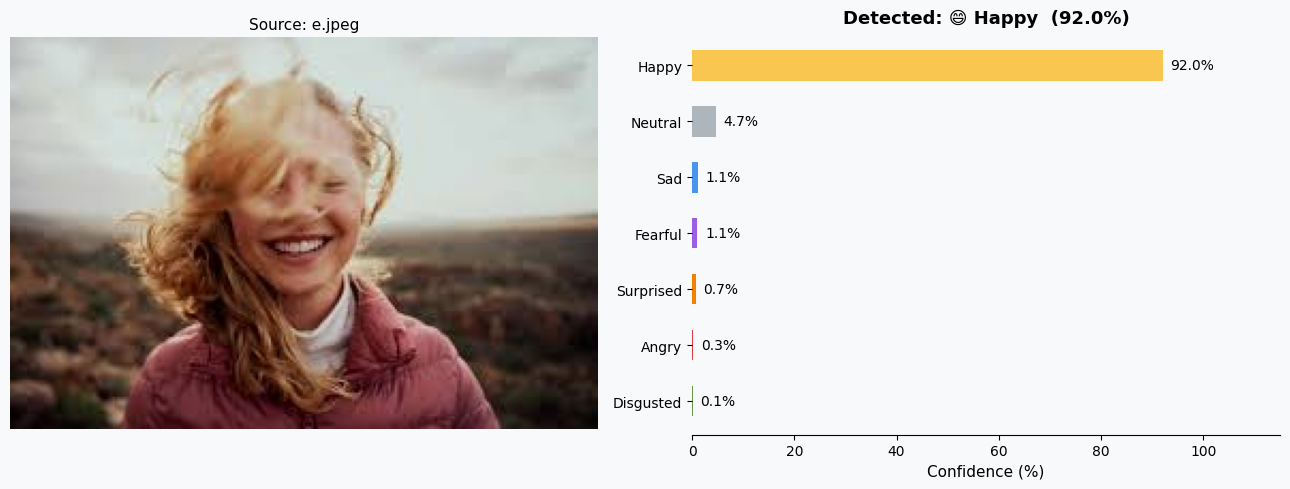


😄  Detected : Happy  (92.0%)
✓  High confidence prediction

📊 All Scores:
  Happy          92.0%  ████████████████████████████████████
  Neutral         4.7%  █
  Sad             1.1%  
  Fearful         1.1%  
  Surprised       0.7%  
  Angry           0.3%  
  Disgusted       0.1%  


In [ ]:
# ============================================================
# EMOTION DETECTOR — FIXED WEBCAM VERSION
# Webcam renders properly inside Colab output
# ============================================================

!pip install -q transformers torch torchvision Pillow

from transformers import pipeline
from PIL import Image
from google.colab import files, output
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import base64, io

# ── Load model
print("Loading model... (takes ~30 seconds first time)")
classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)
print("✓ Model ready!\n")

# ── Labels & styling
candidate_labels = [
    "a person feeling happy and smiling",
    "a person feeling sad or crying",
    "a person feeling angry or furious",
    "a person feeling surprised or shocked",
    "a person feeling disgusted",
    "a person feeling fearful or scared",
    "a person with a neutral calm expression"
]
display_names = {
    "a person feeling happy and smiling"     : "Happy",
    "a person feeling sad or crying"         : "Sad",
    "a person feeling angry or furious"      : "Angry",
    "a person feeling surprised or shocked"  : "Surprised",
    "a person feeling disgusted"             : "Disgusted",
    "a person feeling fearful or scared"     : "Fearful",
    "a person with a neutral calm expression": "Neutral"
}
bar_colors = {
    "Happy":"#f9c74f","Sad":"#4895ef","Angry":"#e63946",
    "Surprised":"#f77f00","Disgusted":"#6a994e",
    "Fearful":"#9b5de5","Neutral":"#adb5bd"
}
emojis = {
    "Happy":"😄","Sad":"😢","Angry":"😡","Surprised":"😲",
    "Disgusted":"🤢","Fearful":"😨","Neutral":"😐"
}

# ════════════════════════════════════════
# CORE ANALYSIS FUNCTION
# ════════════════════════════════════════
def analyse_emotion(img, source_label="Image"):
    print(f"\n🔍 Analysing {source_label}...")
    results = classifier(img, candidate_labels=candidate_labels)
    results = sorted(results, key=lambda x: x['score'], reverse=True)

    top       = results[0]
    top_name  = display_names[top['label']]
    top_score = top['score'] * 100
    final_name  = "Neutral" if top_score < 30 else top_name
    final_score = top_score
    emoji = emojis[final_name]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#f8f9fa')
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f"Source: {source_label}", fontsize=11)

    names  = [display_names[r['label']] for r in results]
    scores = [r['score'] * 100          for r in results]
    colors = [bar_colors[n]             for n in names]
    bars   = ax2.barh(names, scores, color=colors, height=0.55, edgecolor='none')
    ax2.set_xlim(0, 115)
    ax2.set_facecolor('#f8f9fa')
    ax2.set_xlabel("Confidence (%)", fontsize=11)
    ax2.set_title(f"Detected: {emoji} {final_name}  ({final_score:.1f}%)",
                  fontsize=13, fontweight='bold')
    ax2.invert_yaxis()
    ax2.spines[['top','right','left']].set_visible(False)
    for bar, score in zip(bars, scores):
        ax2.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2,
                 f"{score:.1f}%", va='center', fontsize=10)
    plt.tight_layout(); plt.show()

    print(f"\n{emoji}  Detected : {final_name}  ({final_score:.1f}%)")
    if top_score < 30:
        print("⚠  Low confidence — make sure face is clearly visible")
    elif top_score < 60:
        print("⚠  Moderate confidence — try better lighting")
    else:
        print("✓  High confidence prediction")

    print("\n📊 All Scores:")
    for r in results:
        name = display_names[r['label']]
        pct  = r['score'] * 100
        print(f"  {name:12s}  {pct:5.1f}%  {'█' * int(pct/2.5)}")

# ════════════════════════════════════════
# OPTION 1 — WEBCAM (FIXED — renders inside Colab)
# ════════════════════════════════════════
def capture_from_webcam():
    # This HTML+JS renders the camera INSIDE the output cell
    display(HTML("""
    <div id="webcam-container" style="
        background:#1e1e2e; padding:20px; border-radius:12px;
        text-align:center; font-family:sans-serif; max-width:480px;
    ">
      <h3 style="color:white; margin:0 0 12px 0">📷 Live Emotion Capture</h3>
      <video id="camFeed" autoplay playsinline style="
          width:440px; border-radius:8px; border:2px solid #4895ef;
      "></video>
      <canvas id="snapCanvas" style="display:none"></canvas>
      <br><br>
      <button onclick="snapPhoto()" style="
          padding:10px 28px; font-size:15px; background:#4895ef;
          color:white; border:none; border-radius:8px; cursor:pointer;
          margin-right:10px;
      ">📸 Capture</button>
      <button onclick="stopCam()" style="
          padding:10px 18px; font-size:15px; background:#e63946;
          color:white; border:none; border-radius:8px; cursor:pointer;
      ">✕ Cancel</button>
      <p id="camStatus" style="color:#adb5bd; margin-top:10px; font-size:13px">
          Starting camera...
      </p>
    </div>

    <script>
      var camStream = null;

      // Start camera
      navigator.mediaDevices.getUserMedia({video: {facingMode:'user'}, audio:false})
        .then(function(stream) {
          camStream = stream;
          document.getElementById('camFeed').srcObject = stream;
          document.getElementById('camStatus').innerText =
              '✓ Camera ready — click Capture when ready!';
        })
        .catch(function(err) {
          document.getElementById('camStatus').innerText =
              '❌ Camera error: ' + err.message;
        });

      function snapPhoto() {
          var video  = document.getElementById('camFeed');
          var canvas = document.getElementById('snapCanvas');
          canvas.width  = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          var dataURL = canvas.toDataURL('image/jpeg', 0.95);
          document.getElementById('camStatus').innerText =
              '✓ Photo captured! Analysing...';
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          // Send to Python
          google.colab.kernel.invokeFunction('recv_frame', [dataURL], {});
      }

      function stopCam() {
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          document.getElementById('camStatus').innerText = '❌ Cancelled.';
          google.colab.kernel.invokeFunction('recv_frame', [null], {});
      }
    </script>
    """))

    def recv_frame(data):
        if data is None:
            print("❌ Capture cancelled.")
            return
        _, encoded = data.split(',', 1)
        img = Image.open(io.BytesIO(base64.b64decode(encoded))).convert("RGB")
        analyse_emotion(img, source_label="Webcam Capture")

    output.register_callback('recv_frame', recv_frame)

# ════════════════════════════════════════
# OPTION 2 — UPLOAD FROM DEVICE
# ════════════════════════════════════════
def upload_from_device():
    print("📁 Please upload your image:\n")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded.")
        return
    for fn, data in uploaded.items():
        img = Image.open(io.BytesIO(data)).convert("RGB")
        analyse_emotion(img, source_label=fn)

# ════════════════════════════════════════
# MAIN MENU
# ════════════════════════════════════════
print("=" * 48)
print("        🎭  EMOTION DETECTOR")
print("=" * 48)
print()

btn_webcam = widgets.Button(
    description='📷  Webcam Capture',
    layout=widgets.Layout(width='220px', height='48px'),
    style=dict(button_color='#4895ef')
)
btn_upload = widgets.Button(
    description='📁  Upload Image',
    layout=widgets.Layout(width='220px', height='48px'),
    style=dict(button_color='#6a994e')
)

def on_webcam(b):
    clear_output(wait=True)
    capture_from_webcam()

def on_upload(b):
    clear_output(wait=True)
    upload_from_device()

btn_webcam.on_click(on_webcam)
btn_upload.on_click(on_upload)

display(widgets.HTML("<b style='font-size:15px'>Choose how to provide your image:</b>"))
display(widgets.HBox([btn_webcam, btn_upload],
        layout=widgets.Layout(gap='16px', margin='12px 0')))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8248 - loss: 0.5849 - val_accuracy: 0.8897 - val_loss: 0.4272
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9484 - loss: 0.2674 - val_accuracy: 0.9740 - val_loss: 0.1448
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0987 - val_accuracy: 0.9892 - val_loss: 0.0715
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9890 - loss: 0.0557 - val_accuracy: 0.9892 - val_loss: 0.0533
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0396 - val_accuracy: 0.9892 - val_loss: 0.0469
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9926 - loss: 0.0303 - val_accuracy: 0.9901 - val_loss: 0.0430
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9944 - loss: 0.0248 - val_accuracy: 0.9883 - val_loss: 0.0424
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.0206 - val_accuracy: 0.9883 - val

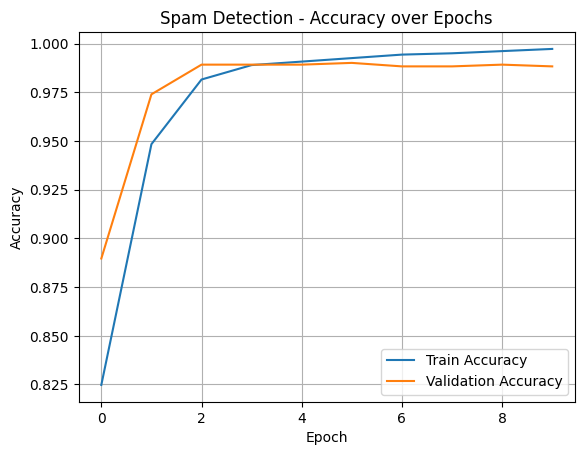


Binary Cross-Entropy is used for binary classification tasks.
It calculates the loss as: - (y * log(p) + (1 - y) * log(1 - p))
Where:
  y = actual label (0 or 1)
  p = predicted probability (output of sigmoid)
It penalizes confident incorrect predictions more heavily.



In [ ]:

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load SMS Spam Dataset
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(url, header=None, names=['label', 'message'])

#  Encode labels (ham = 0, spam = 1)
df['label'] = LabelEncoder().fit_transform(df['label'])

#  Split data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

#  TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

#  Build Neural Network Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_vec.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

#  Compile the Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#  Train the Model
history = model.fit(X_train_vec, y_train, epochs=10,
                    validation_data=(X_test_vec, y_test), verbose=1)

#  Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Spam Detection - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#  Explanation:
print("""
Binary Cross-Entropy is used for binary classification tasks.
It calculates the loss as: - (y * log(p) + (1 - y) * log(1 - p))
Where:
  y = actual label (0 or 1)
  p = predicted probability (output of sigmoid)
It penalizes confident incorrect predictions more heavily.
""")


📁 Please upload your plant leaf image:



Saving i.jpeg to i.jpeg

🔍 Analysing i.jpeg...


/tmp/ipykernel_621/726096317.py:186: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


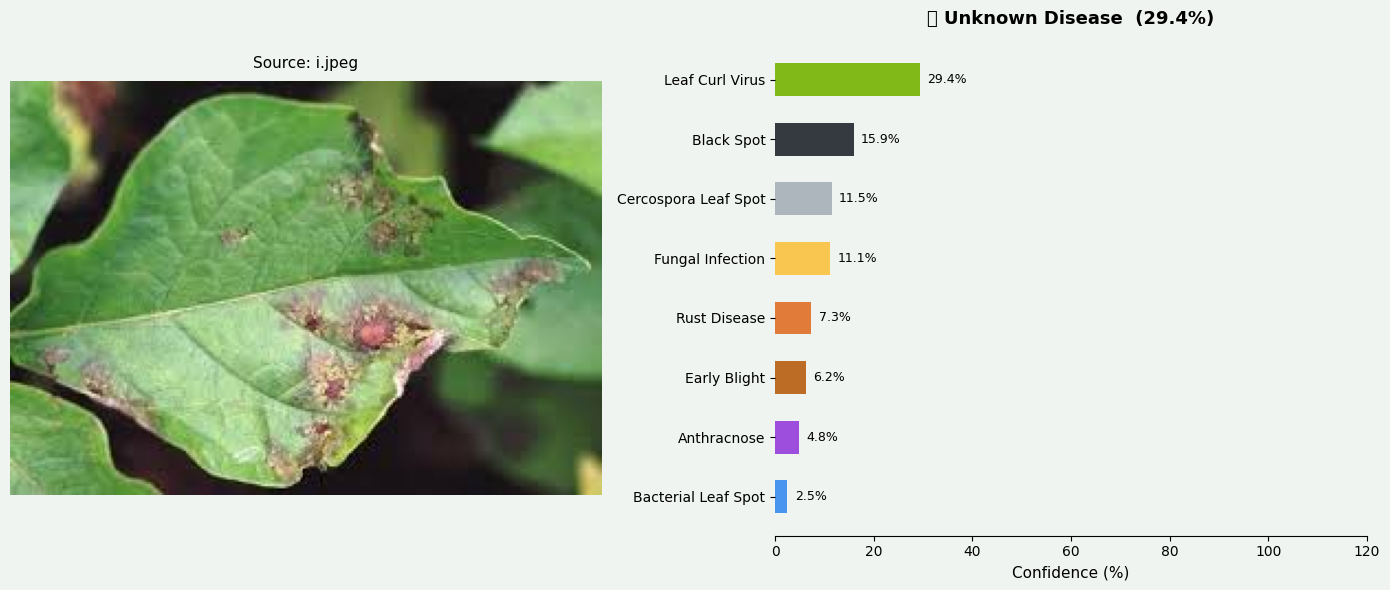


❓  Detected      : Unknown Disease
✓   Confidence   : 29.4%
⚠   Could not identify — try a clearer, closer photo of the leaf

───────────────────────────────────────────────────────
💊  TREATMENT / ADVICE
───────────────────────────────────────────────────────
  Take a clearer photo of the leaf. Consult a local plant pathologist.
───────────────────────────────────────────────────────

📊 Top 8 Scores:
  Leaf Curl Virus             29.4%  ███████████
  Black Spot                  15.9%  ██████
  Cercospora Leaf Spot        11.5%  ████
  Fungal Infection            11.1%  ████
  Rust Disease                 7.3%  ██
  Early Blight                 6.2%  ██
  Anthracnose                  4.8%  █
  Bacterial Leaf Spot          2.5%  


In [ ]:
# ============================================================
# PLANT DISEASE DETECTOR — SINGLE CELL, COMPLETE, NO ERRORS
# Uses HuggingFace zero-shot image classifier (CLIP)
# Option 1: Take photo using webcam (live capture)
# Option 2: Upload image from device
# Detects 15 common plant diseases + Healthy + Other
# ============================================================

!pip install -q transformers torch torchvision Pillow

from transformers import pipeline
from PIL import Image
from google.colab import files, output
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import base64, io

# ── Load model
print("Loading model... (takes ~30 seconds first time)")
classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)
print("✓ Model ready!\n")

# ── Disease labels
candidate_labels = [
    "a healthy plant leaf with no disease",
    "a plant leaf with yellow spots caused by fungal infection",
    "a plant leaf with brown rust spots",
    "a plant leaf with powdery white mildew coating",
    "a plant leaf with black spots disease",
    "a plant leaf with early blight brown lesions",
    "a plant leaf with late blight dark water soaked lesions",
    "a plant leaf with leaf curl virus symptoms",
    "a plant leaf with mosaic virus yellow green patches",
    "a plant leaf with anthracnose dark sunken lesions",
    "a plant leaf with bacterial leaf spot water soaked lesions",
    "a plant leaf with downy mildew pale yellow patches",
    "a plant leaf with cercospora leaf spot grey center",
    "a plant leaf with sooty mold black coating",
    "a plant leaf with nutrient deficiency yellowing",
    "a plant leaf with root rot wilting drooping",
    "a diseased plant leaf"   # catch-all
]

display_names = {
    "a healthy plant leaf with no disease"                        : "Healthy ✅",
    "a plant leaf with yellow spots caused by fungal infection"   : "Fungal Infection",
    "a plant leaf with brown rust spots"                          : "Rust Disease",
    "a plant leaf with powdery white mildew coating"              : "Powdery Mildew",
    "a plant leaf with black spots disease"                       : "Black Spot",
    "a plant leaf with early blight brown lesions"                : "Early Blight",
    "a plant leaf with late blight dark water soaked lesions"     : "Late Blight",
    "a plant leaf with leaf curl virus symptoms"                  : "Leaf Curl Virus",
    "a plant leaf with mosaic virus yellow green patches"         : "Mosaic Virus",
    "a plant leaf with anthracnose dark sunken lesions"           : "Anthracnose",
    "a plant leaf with bacterial leaf spot water soaked lesions"  : "Bacterial Leaf Spot",
    "a plant leaf with downy mildew pale yellow patches"          : "Downy Mildew",
    "a plant leaf with cercospora leaf spot grey center"          : "Cercospora Leaf Spot",
    "a plant leaf with sooty mold black coating"                  : "Sooty Mold",
    "a plant leaf with nutrient deficiency yellowing"             : "Nutrient Deficiency",
    "a plant leaf with root rot wilting drooping"                 : "Root Rot",
    "a diseased plant leaf"                                       : "Unknown Disease"
}

bar_colors = {
    "Healthy ✅"           : "#57cc99",
    "Fungal Infection"     : "#f9c74f",
    "Rust Disease"         : "#e07b39",
    "Powdery Mildew"       : "#dee2e6",
    "Black Spot"           : "#343a40",
    "Early Blight"         : "#bc6c25",
    "Late Blight"          : "#6d4c41",
    "Leaf Curl Virus"      : "#80b918",
    "Mosaic Virus"         : "#aacc00",
    "Anthracnose"          : "#9d4edd",
    "Bacterial Leaf Spot"  : "#4895ef",
    "Downy Mildew"         : "#b5e48c",
    "Cercospora Leaf Spot" : "#adb5bd",
    "Sooty Mold"           : "#495057",
    "Nutrient Deficiency"  : "#ffb703",
    "Root Rot"             : "#7f5539",
    "Unknown Disease"      : "#ced4da"
}

emojis = {
    "Healthy ✅"           : "🌿",
    "Fungal Infection"     : "🍄",
    "Rust Disease"         : "🟤",
    "Powdery Mildew"       : "⬜",
    "Black Spot"           : "⚫",
    "Early Blight"         : "🟫",
    "Late Blight"          : "🫧",
    "Leaf Curl Virus"      : "🌀",
    "Mosaic Virus"         : "🟡",
    "Anthracnose"          : "🟣",
    "Bacterial Leaf Spot"  : "💧",
    "Downy Mildew"         : "🌫️",
    "Cercospora Leaf Spot" : "⚪",
    "Sooty Mold"           : "🖤",
    "Nutrient Deficiency"  : "💛",
    "Root Rot"             : "🪵",
    "Unknown Disease"      : "❓"
}

# ── Treatment tips for each disease
treatments = {
    "Healthy ✅"           : "Your plant looks healthy! Keep watering regularly and ensure proper sunlight.",
    "Fungal Infection"     : "Apply copper-based fungicide. Remove infected leaves. Avoid overhead watering.",
    "Rust Disease"         : "Remove infected leaves immediately. Apply sulfur-based fungicide. Improve air circulation.",
    "Powdery Mildew"       : "Spray neem oil or baking soda solution. Avoid wetting leaves. Ensure good airflow.",
    "Black Spot"           : "Remove affected leaves. Apply fungicide weekly. Keep leaves dry.",
    "Early Blight"         : "Apply chlorothalonil fungicide. Remove lower infected leaves. Rotate crops.",
    "Late Blight"          : "Apply copper fungicide immediately. Destroy infected plants. Avoid wet conditions.",
    "Leaf Curl Virus"      : "No cure — remove infected plant. Control whiteflies/aphids. Use virus-resistant varieties.",
    "Mosaic Virus"         : "No cure — remove infected plant. Control aphids. Disinfect tools after use.",
    "Anthracnose"          : "Apply mancozeb fungicide. Remove infected parts. Avoid overhead irrigation.",
    "Bacterial Leaf Spot"  : "Apply copper bactericide. Remove infected leaves. Avoid working with wet plants.",
    "Downy Mildew"         : "Apply metalaxyl fungicide. Improve drainage. Avoid overcrowding plants.",
    "Cercospora Leaf Spot" : "Apply fungicide with azoxystrobin. Remove infected leaves. Ensure proper spacing.",
    "Sooty Mold"           : "Control insects causing honeydew (aphids/scales). Wipe leaves with soapy water.",
    "Nutrient Deficiency"  : "Test soil pH. Apply balanced NPK fertilizer. Check iron/magnesium levels.",
    "Root Rot"             : "Improve drainage. Reduce watering. Apply fungicide drench. Repot if necessary.",
    "Unknown Disease"      : "Take a clearer photo of the leaf. Consult a local plant pathologist."
}

CONFIDENCE_THRESHOLD = 32

# ════════════════════════════════════════
# CORE ANALYSIS FUNCTION
# ════════════════════════════════════════
def analyse_plant(img, source_label="Image"):
    print(f"\n🔍 Analysing {source_label}...")
    results = classifier(img, candidate_labels=candidate_labels)
    results = sorted(results, key=lambda x: x['score'], reverse=True)

    top       = results[0]
    top_name  = display_names[top['label']]
    top_score = top['score'] * 100

    # Catch-all or low confidence → Unknown Disease
    if top_name == "Unknown Disease" or top_score < CONFIDENCE_THRESHOLD:
        final_name  = "Unknown Disease"
        final_score = top_score
    else:
        final_name  = top_name
        final_score = top_score

    emoji     = emojis[final_name]
    tip       = treatments[final_name]

    # ── Filter catch-all from chart, show top 8
    chart_results = [r for r in results
                     if display_names[r['label']] != "Unknown Disease"][:8]

    names  = [display_names[r['label']] for r in chart_results]
    scores = [r['score'] * 100          for r in chart_results]
    colors = [bar_colors[n]             for n in names]

    # ── Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#f0f4f0')

    # Left — image
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Source: {source_label}", fontsize=11, pad=10)

    # Right — bar chart
    bars = ax2.barh(names, scores, color=colors, height=0.55, edgecolor='none')
    ax2.set_xlim(0, 120)
    ax2.set_facecolor('#f0f4f0')
    ax2.set_xlabel("Confidence (%)", fontsize=11)
    ax2.set_title(f"{emoji} {final_name}  ({final_score:.1f}%)",
                  fontsize=13, fontweight='bold', pad=12)
    ax2.invert_yaxis()
    ax2.spines[['top', 'right', 'left']].set_visible(False)

    for bar, score in zip(bars, scores):
        ax2.text(bar.get_width() + 1.5,
                 bar.get_y() + bar.get_height() / 2,
                 f"{score:.1f}%", va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Console output
    print(f"\n{emoji}  Detected      : {final_name}")
    print(f"✓   Confidence   : {final_score:.1f}%")

    if final_name == "Unknown Disease":
        print("⚠   Could not identify — try a clearer, closer photo of the leaf")
    elif final_score < 55:
        print("⚠   Moderate confidence — ensure good lighting and focus on the leaf")
    else:
        print("✓   High confidence prediction")

    # ── Treatment box
    print("\n" + "─" * 55)
    print("💊  TREATMENT / ADVICE")
    print("─" * 55)
    print(f"  {tip}")
    print("─" * 55)

    print("\n📊 Top 8 Scores:")
    for r in chart_results:
        name = display_names[r['label']]
        pct  = r['score'] * 100
        print(f"  {name:25s}  {pct:5.1f}%  {'█' * int(pct / 2.5)}")


# ════════════════════════════════════════
# OPTION 1 — WEBCAM (renders inside Colab)
# ════════════════════════════════════════
def capture_from_webcam():
    display(HTML("""
    <div style="
        background:#1a2e1a; padding:20px; border-radius:12px;
        text-align:center; font-family:sans-serif; max-width:480px;
    ">
      <h3 style="color:#57cc99; margin:0 0 12px 0">🌿 Plant Disease — Live Capture</h3>
      <video id="camFeed" autoplay playsinline style="
          width:440px; border-radius:8px; border:2px solid #57cc99;
      "></video>
      <canvas id="snapCanvas" style="display:none"></canvas>
      <br><br>
      <button onclick="snapPhoto()" style="
          padding:10px 28px; font-size:15px; background:#57cc99;
          color:#1a2e1a; border:none; border-radius:8px;
          cursor:pointer; font-weight:bold; margin-right:10px;
      ">📸 Capture</button>
      <button onclick="stopCam()" style="
          padding:10px 18px; font-size:15px; background:#e63946;
          color:white; border:none; border-radius:8px; cursor:pointer;
      ">✕ Cancel</button>
      <p id="camStatus" style="color:#adb5bd; margin-top:10px; font-size:13px">
          Starting camera...
      </p>
    </div>

    <script>
      var camStream = null;
      navigator.mediaDevices.getUserMedia({video:{facingMode:'environment'}, audio:false})
        .then(function(stream){
          camStream = stream;
          document.getElementById('camFeed').srcObject = stream;
          document.getElementById('camStatus').innerText =
              '✓ Camera ready — point at the plant leaf and click Capture!';
        })
        .catch(function(err){
          document.getElementById('camStatus').innerText =
              '❌ Camera error: ' + err.message;
        });

      function snapPhoto(){
          var video  = document.getElementById('camFeed');
          var canvas = document.getElementById('snapCanvas');
          canvas.width  = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          var dataURL = canvas.toDataURL('image/jpeg', 0.95);
          document.getElementById('camStatus').innerText =
              '✓ Captured! Analysing leaf...';
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          google.colab.kernel.invokeFunction('recv_plant_frame', [dataURL], {});
      }

      function stopCam(){
          if(camStream) camStream.getTracks().forEach(t => t.stop());
          document.getElementById('camStatus').innerText = '❌ Cancelled.';
          google.colab.kernel.invokeFunction('recv_plant_frame', [null], {});
      }
    </script>
    """))

    def recv_plant_frame(data):
        if data is None:
            print("❌ Capture cancelled.")
            return
        _, encoded = data.split(',', 1)
        img = Image.open(io.BytesIO(base64.b64decode(encoded))).convert("RGB")
        analyse_plant(img, source_label="Webcam Capture")

    output.register_callback('recv_plant_frame', recv_plant_frame)


# ════════════════════════════════════════
# OPTION 2 — UPLOAD FROM DEVICE
# ════════════════════════════════════════
def upload_from_device():
    print("📁 Please upload your plant leaf image:\n")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded.")
        return
    for fn, data in uploaded.items():
        img = Image.open(io.BytesIO(data)).convert("RGB")
        analyse_plant(img, source_label=fn)


# ════════════════════════════════════════
# MAIN MENU
# ════════════════════════════════════════
def show_menu():
    print("=" * 50)
    print("     🌿  PLANT DISEASE DETECTOR")
    print("=" * 50)
    print()

    btn_webcam = widgets.Button(
        description='📷  Webcam Capture',
        layout=widgets.Layout(width='220px', height='48px'),
        style=dict(button_color='#57cc99')
    )
    btn_upload = widgets.Button(
        description='📁  Upload Image',
        layout=widgets.Layout(width='220px', height='48px'),
        style=dict(button_color='#80b918')
    )

    def on_webcam(b):
        clear_output(wait=True)
        capture_from_webcam()

    def on_upload(b):
        clear_output(wait=True)
        upload_from_device()

    btn_webcam.on_click(on_webcam)
    btn_upload.on_click(on_upload)

    display(widgets.HTML(
        "<b style='font-size:15px'>Choose how to provide your plant image:</b>"))
    display(widgets.HBox([btn_webcam, btn_upload],
            layout=widgets.Layout(gap='16px', margin='12px 0')))

show_menu()

In [ ]:
pip install tflite-model-maker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 41.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
pip install tensorflow tensorflow-hub

In [ ]:
# The tflite-model-maker library (version 0.4.3) is incompatible with Python 3.12,
# which is the current version in this Colab environment.
# Its dependencies, like tensorflow==2.3.0 and numpy<1.23.4, cannot be installed
# on Python 3.12, causing the ModuleNotFoundError.
# To use tflite-model-maker, you would need to run this code in an environment
# with an older Python version (e.g., Python 3.8 or 3.9).

# !pip install --upgrade pip
# !pip install tflite-model-maker --force-reinstall --ignore-installed ruamel.yaml --user

# import tflite_model_maker as mm
# from tflite_model_maker import image_classifier
# from tflite_model_maker.image_classifier import Dataloader
import tensorflow as tf

In [ ]:
!pip install tensorflow --quiet

import tensorflow as tf
import numpy as np

# ── Load Flowers Dataset (built-in, auto-downloads) ────────────
import pathlib, urllib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("Classes found:", [item.name for item in data_dir.glob('*') if item.is_dir()])

# ── Configuration ──────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
AUTOTUNE   = tf.data.AUTOTUNE

# ── Load Dataset ───────────────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ── Performance Tuning ─────────────────────────────────────────
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ── Build Model ────────────────────────────────────────────────
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Train ───────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

# ── Evaluate ────────────────────────────────────────────────────
loss, accuracy = model.evaluate(test_ds)
print(f"\n✅ Test accuracy: {accuracy:.4f}")

# ── Export to TFLite ────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('flower_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ flower_model.tflite saved!")

# ── Quick Prediction Test ───────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path='flower_model.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Grab one test image
for images, labels in test_ds.take(1):
    img = images[0].numpy()
    img_input = np.expand_dims(img, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], img_input)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = class_names[np.argmax(output)]
    print(f"\n🌸 Predicted: {predicted_class} (confidence: {np.max(output):.2f})")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Classes found: ['flower_photos']
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Classes: ['flower_photos']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


92/92 ━━━━━━━━━━━━━━━━━━━━ 57s 360ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
keras_model_path = '/content/Cats & Dogs Model.h5'
model = tf.keras.models.load_model(keras_model_path)


NameError: name 'tf' is not defined

In [ ]:
import tensorflow as tf

# Placeholder for data loading
# You need to load or create your 'train_images' and 'train_labels' (and 'val_images'/'val_labels' if applicable)
# For example, using ImageDataGenerator or tf.keras.utils.image_dataset_from_directory
# train_images = ...
# train_labels = ...

model = tf.keras.models.Sequential([
tf.keras.layers.InputLayer(shape=(150, 150, 3)), # Changed input_shape to shape
tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
tf.keras.layers.MaxPooling2D(),
tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
tf.keras.layers.MaxPooling2D(),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dense(2, activation='softmax')
])

# 2 classes

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
# The following line will still produce an error until train_images and train_labels are defined.
# model.fit(train_images, train_labels, epochs=10, validation_split=0.2)